In [1]:
# Cell 1 — Imports + global config (chi^2 only; fixed DM)

import os, glob, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FIELDS_DIR = "sdss_data/fields"
PATTERN = os.path.join(FIELDS_DIR, "sdss_*.csv")

# quality cuts
ERR_MAX = 0.15
G0_MAX  = 23.5
R0_MAX  = 23.5

# Sagittarius reference distance
d_pc   = 33_400.0
DM_SGR = 5.0 * np.log10(d_pc / 10.0)  # ~17.62

# chi^2 candidate threshold (2 dof: g and r)
CHI2_THRESH = 6.18  # ~95% for 2 dof; tune

# optional speed-up: only consider iso points within this window in apparent g
DG_WINDOW = 0.50

# reproducibility
random.seed(0)

# MSTO box (for overdensity)
MSTO = dict(gmin=20.0, gmax=22.5, cmin=0.15, cmax=0.65)

print(f"DM_SGR={DM_SGR:.4f}, CHI2_THRESH={CHI2_THRESH}, DG_WINDOW={DG_WINDOW}, MSTO={MSTO}")

DM_SGR=17.6187, CHI2_THRESH=6.18, DG_WINDOW=0.5, MSTO={'gmin': 20.0, 'gmax': 22.5, 'cmin': 0.15, 'cmax': 0.65}


In [2]:
# Cell 2 — Load Dartmouth isochrones and shift them to apparent mags at DM_SGR

from isochrones.dartmouth_iso import load_isochrones
isos = load_isochrones("isochrones")
iso5  = isos["5gyr"]
iso13 = isos["13gyr"]

def iso_app_gr(iso, DM):
    """Return isochrone arrays in apparent g,r and derived color at distance modulus DM."""
    df_iso = iso.df
    g_app = df_iso["sdss_g"].to_numpy() + DM
    r_app = df_iso["sdss_r"].to_numpy() + DM
    c_app = g_app - r_app
    return g_app, r_app, c_app

g5_app,  r5_app,  c5_app  = iso_app_gr(iso5,  DM_SGR)
g13_app, r13_app, c13_app = iso_app_gr(iso13, DM_SGR)

In [3]:
# Cell 3 — Load all SDSS fields (target + controls), compute dereddened mags + errors, apply quality cuts

def load_field_csv(path):
    df0 = pd.read_csv(path, comment="#")

    # dereddened mags/colors
    df0["g0"]  = df0["psfMag_g"] - df0["extinction_g"]
    df0["r0"]  = df0["psfMag_r"] - df0["extinction_r"]
    df0["g_r"] = df0["g0"] - df0["r0"]

    # errors (color error via quadrature sum)
    df0["sig_g"]  = df0["psfMagErr_g"]
    df0["sig_r"]  = df0["psfMagErr_r"]
    df0["sig_gr"] = np.sqrt(df0["sig_g"]**2 + df0["sig_r"]**2)

    # light quality mask
    m = (
        (df0["sig_g"] < ERR_MAX) &
        (df0["sig_r"] < ERR_MAX) &
        (df0["g0"] < G0_MAX) &
        (df0["r0"] < R0_MAX)
    )
    return df0[m].copy()

paths = sorted([p for p in glob.glob(PATTERN) if "FAILED_" not in os.path.basename(p)])
if not paths:
    raise FileNotFoundError(f"No files matched {PATTERN}")

fields = []
for p in paths:
    fid = os.path.basename(p).replace("sdss_", "").replace(".csv", "")
    fields.append((fid, load_field_csv(p)))

fields = sorted(fields, key=lambda t: (t[0] != "target", t[0]))
field_map = {fid: df for fid, df in fields}

print(f"Loaded {len(fields)} fields. Target present? {'target' in field_map}")

Loaded 14 fields. Target present? True


In [4]:
# Cell 4 — Core: min chi^2 to an isochrone at fixed DM (no DM fitting)

def min_chi2_fixed_dm(star_g0, star_r0, sig_g, sig_r, g_iso, r_iso, dg_window=0.5):
    """
    For each star, compute min chi^2 to an isochrone with DM fixed (iso already in apparent g,r).

    chi^2_i = ((g0 - g_iso_i)/sig_g)^2 + ((r0 - r_iso_i)/sig_r)^2
    We restrict candidate iso points to those with |g_iso - g0| <= dg_window for speed.
    """
    star_g0 = np.asarray(star_g0)
    star_r0 = np.asarray(star_r0)
    sig_g   = np.asarray(sig_g)
    sig_r   = np.asarray(sig_r)

    chi2_min = np.full_like(star_g0, np.inf, dtype=float)

    for j in range(len(star_g0)):
        m = np.abs(g_iso - star_g0[j]) <= dg_window
        if not np.any(m):
            continue
        dg = (star_g0[j] - g_iso[m]) / max(sig_g[j], 1e-6)
        dr = (star_r0[j] - r_iso[m]) / max(sig_r[j], 1e-6)
        chi2 = dg*dg + dr*dr
        chi2_min[j] = np.min(chi2)

    return chi2_min

# Compute chi^2 + candidates for every field
for fid, dfp in fields:
    chi2_5  = min_chi2_fixed_dm(dfp["g0"], dfp["r0"], dfp["sig_g"], dfp["sig_r"], g5_app,  r5_app,  dg_window=DG_WINDOW)
    chi2_13 = min_chi2_fixed_dm(dfp["g0"], dfp["r0"], dfp["sig_g"], dfp["sig_r"], g13_app, r13_app, dg_window=DG_WINDOW)

    dfp["chi2_5"] = chi2_5
    dfp["chi2_13"] = chi2_13

    dfp["cand_5"]  = np.isfinite(chi2_5)  & (chi2_5  < CHI2_THRESH)
    dfp["cand_13"] = np.isfinite(chi2_13) & (chi2_13 < CHI2_THRESH)
    dfp["cand_either"] = dfp["cand_5"] | dfp["cand_13"]

    # MSTO mask + MSTO candidates
    dfp["in_msto"] = (
        (dfp["g0"] >= MSTO["gmin"]) & (dfp["g0"] <= MSTO["gmax"]) &
        (dfp["g_r"] >= MSTO["cmin"]) & (dfp["g_r"] <= MSTO["cmax"])
    )
    dfp["cand_msto"] = dfp["cand_either"] & dfp["in_msto"]

print("Computed chi^2 + candidates for all fields.")

Computed chi^2 + candidates for all fields.


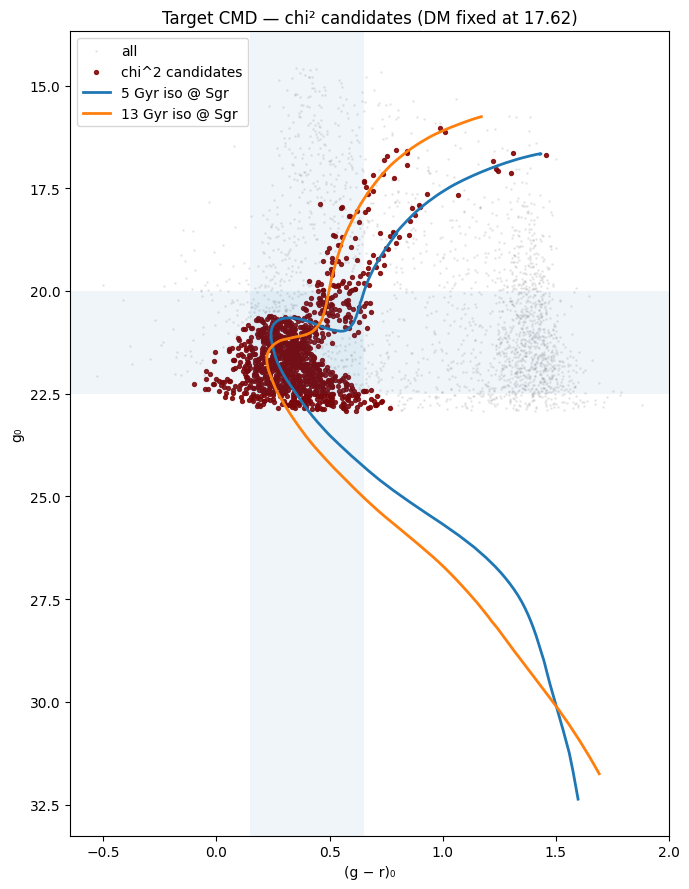

Target candidates: 1110 out of 3206
Target MSTO candidates: 775 out of MSTO N= 899


In [9]:
# Cell 5 — Quick plot: target CMD with candidates + isochrones

df_t = field_map["target"]

plt.figure(figsize=(7,9))
plt.scatter(df_t["g_r"], df_t["g0"], s=1, alpha=0.12, color="gray", label="all")
plt.scatter(df_t.loc[df_t["cand_either"], "g_r"],
            df_t.loc[df_t["cand_either"], "g0"],
            s=8, alpha=0.85, color="maroon", label="chi^2 candidates")

plt.plot(c5_app,  g5_app,  lw=2, label="5 Gyr iso @ Sgr")
plt.plot(c13_app, g13_app, lw=2, label="13 Gyr iso @ Sgr")

# MSTO box overlay
plt.axvspan(MSTO["cmin"], MSTO["cmax"], alpha=0.07)
plt.axhspan(MSTO["gmin"], MSTO["gmax"], alpha=0.07)

plt.gca().invert_yaxis()
plt.xlabel("(g − r)₀")
plt.ylabel("g₀")
plt.title(f"Target CMD — chi² candidates (DM fixed at {DM_SGR:.2f})")
plt.legend()
plt.tight_layout()
plt.show()

print("Target candidates:", int(df_t["cand_either"].sum()), "out of", len(df_t))
print("Target MSTO candidates:", int(df_t["cand_msto"].sum()), "out of MSTO N=", int(df_t["in_msto"].sum()))

,field,N_msto,N_cand_msto,f_cand_msto
1,glon_080,584,479,0.820205
2,glon_085,570,433,0.759649
3,glon_090,599,469,0.782972
4,glon_095,555,423,0.762162
5,glon_100,545,372,0.682569
6,glon_105,569,422,0.741652
7,glon_110,539,402,0.745826
8,glon_115,548,413,0.753650
9,glon_120,519,391,0.753372
10,glon_125,614,467,0.760586


=== Overdensity (MSTO only, chi^2 candidates @ fixed DM) ===
Target:   N=899, N_cand=775, f=0.86207
Controls: mean f=0.76896, std f=0.03845 (n=13)
Significance: S = 2.42 σ
Empirical one-sided p-value (controls >= target): p = 0.071


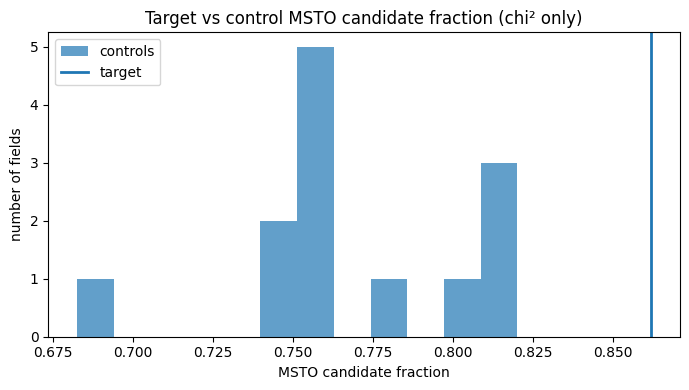

In [6]:
# Cell 6 — MSTO overdensity summary (target vs controls)

rows = []
for fid, dfp in fields:
    N  = int(dfp["in_msto"].sum())
    Nc = int(dfp["cand_msto"].sum())
    f  = (Nc / N) if N > 0 else np.nan
    rows.append({"field": fid, "N_msto": N, "N_cand_msto": Nc, "f_cand_msto": f})

summary = pd.DataFrame(rows).sort_values("field")
display(summary)

target_row = summary[summary["field"] == "target"].iloc[0]
controls = summary[(summary["field"] != "target") & np.isfinite(summary["f_cand_msto"])].copy()

mu = controls["f_cand_msto"].mean()
sigma = controls["f_cand_msto"].std(ddof=1)
S = (target_row["f_cand_msto"] - mu) / sigma if sigma > 0 else np.nan

print("=== Overdensity (MSTO only, chi^2 candidates @ fixed DM) ===")
print(f"Target:   N={int(target_row['N_msto'])}, N_cand={int(target_row['N_cand_msto'])}, f={target_row['f_cand_msto']:.5f}")
print(f"Controls: mean f={mu:.5f}, std f={sigma:.5f} (n={len(controls)})")
print(f"Significance: S = {S:.2f} σ")

ctrl_f = controls["f_cand_msto"].to_numpy()
p = (np.sum(ctrl_f >= target_row["f_cand_msto"]) + 1) / (len(ctrl_f) + 1)
print(f"Empirical one-sided p-value (controls >= target): p = {p:.3f}")

plt.figure(figsize=(7,4))
plt.hist(ctrl_f, bins=12, alpha=0.7, label="controls")
plt.axvline(target_row["f_cand_msto"], linewidth=2, label="target")
plt.xlabel("MSTO candidate fraction")
plt.ylabel("number of fields")
plt.title("Target vs control MSTO candidate fraction (chi² only)")
plt.legend()
plt.tight_layout()
plt.show()

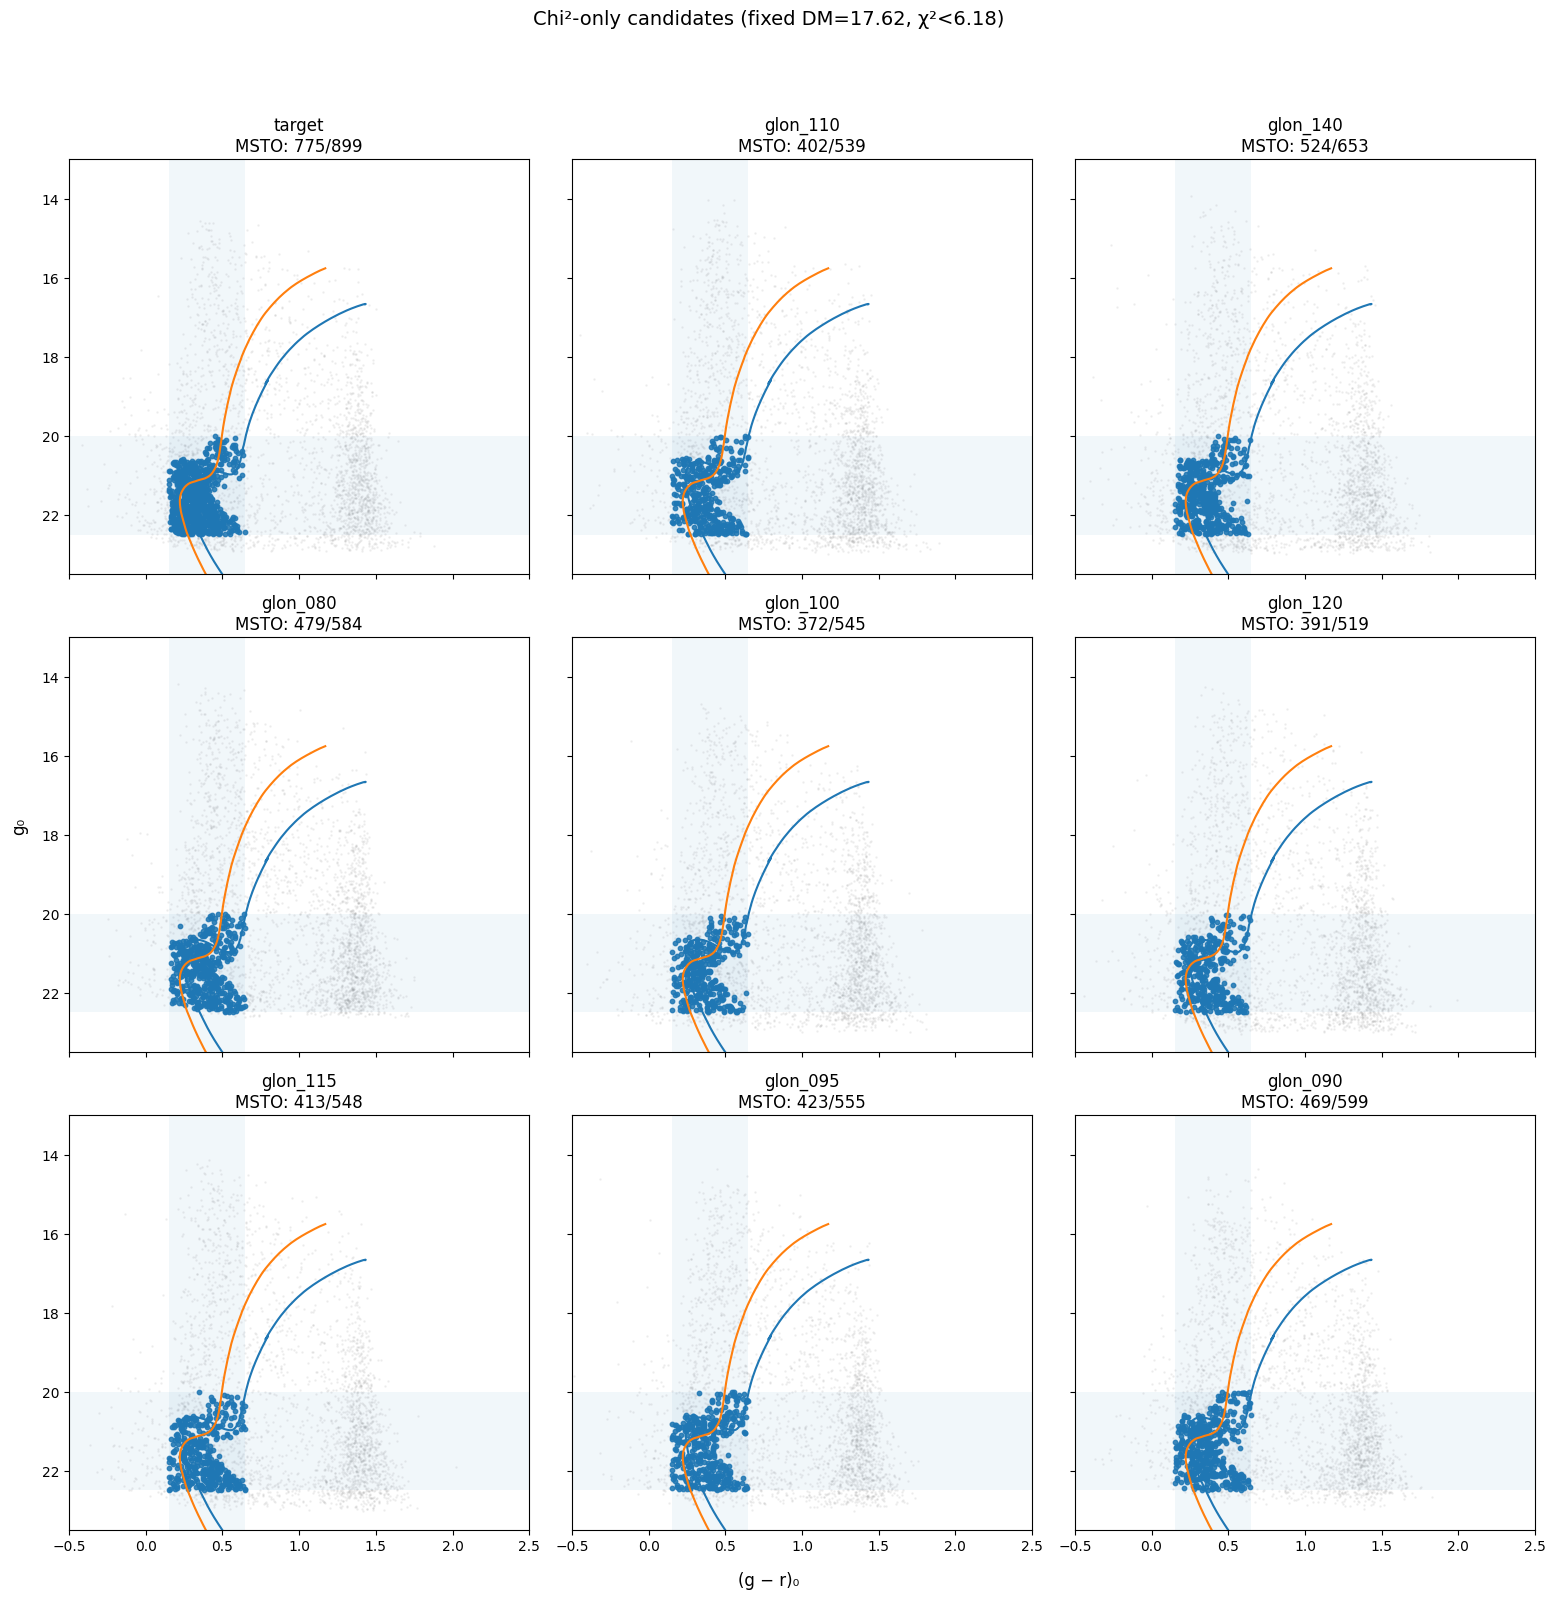

In [7]:
# Cell 7 — (Optional but useful) Plot a grid: target + a few random controls

control_ids = [fid for fid in field_map.keys() if fid != "target"]
n_controls_to_plot = min(8, len(control_ids))
plot_ids = ["target"] + random.sample(control_ids, k=n_controls_to_plot)

n = len(plot_ids)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 5.5*nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for ax, fid in zip(axes, plot_ids):
    dfp = field_map[fid]

    ax.scatter(dfp["g_r"], dfp["g0"], s=1, alpha=0.08, color="gray")
    ax.scatter(dfp.loc[dfp["cand_msto"], "g_r"], dfp.loc[dfp["cand_msto"], "g0"],
               s=10, alpha=0.85)

    ax.plot(c5_app,  g5_app,  lw=1.5)
    ax.plot(c13_app, g13_app, lw=1.5)

    ax.axvspan(MSTO["cmin"], MSTO["cmax"], alpha=0.06)
    ax.axhspan(MSTO["gmin"], MSTO["gmax"], alpha=0.06)

    N  = int(dfp["in_msto"].sum())
    Nc = int(dfp["cand_msto"].sum())
    ax.set_title(f"{fid}\nMSTO: {Nc}/{N}")

    ax.invert_yaxis()
    ax.set_xlim(-0.5, 2.5)
    ax.set_ylim(23.5, 13)

for k in range(len(plot_ids), len(axes)):
    axes[k].axis("off")

fig.text(0.5, 0.04, "(g − r)₀", ha="center", fontsize=12)
fig.text(0.04, 0.5, "g₀", va="center", rotation="vertical", fontsize=12)

fig.suptitle(f"Chi²-only candidates (fixed DM={DM_SGR:.2f}, χ²<{CHI2_THRESH})", y=0.995, fontsize=14)
plt.tight_layout(rect=[0.05, 0.05, 0.98, 0.96])
plt.show()